# Results Plotting Notebook

This notebook consumes `results.pt` produced by `collect_results.py` and generates Figures 1 through 8.

Expected top-level keys:

```python
{
    "motivation": [...],
    "insight": [...],
    "trace": [...],
    "results": [...],
}
```


In [1]:
import os
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

sns.set_palette("tab10")
sns.set_style("whitegrid")
plt.rc("font", size=12)

# =========================
# User parameters
# =========================
RESULTS_PT = Path("./results.pt")
PLOTS_DIR = Path("./plots_results")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 16

# For figures where the prompt does not specify speculative_length.
TRACE_SPECULATIVE_LENGTH = 3
TOPK_SPECULATIVE_LENGTH = 3
CONF_SPECULATIVE_LENGTH = 3

# Figure 5 explicitly requires k=3 and k=7.
INTRA_BATCH_SPECULATIVE_LENGTHS = [3, 7]

# Optional filters. Set to None to include everything.
METHOD_FILTER = None
DATASET_FILTER = None
MODEL_PAIR_FILTER = None

# Pretty names for common methods.
METHOD_RENAME = {
    "sync": "Speculative Decoding",
    "hierarchical": "Hierarchical Verification",
    "hierarchical_verification": "Hierarchical Verification",
    "pivot": "Pivot",
    "pivot_hierarchical": "Pivot + Hierarchical Verification",
    "ar": "Auto-regressive",
}

METHOD_ORDER = [
    "Auto-regressive",
    "Speculative Decoding",
    "Hierarchical Verification",
    "Pivot",
    "Pivot + Hierarchical Verification",
]

FIGSIZE_WIDE = (8, 2)
FIGSIZE_TALL = (8, 3)
FIGSIZE_GRID = (8, 5)
DPI = 300


In [2]:
# =========================
# Load and normalize data
# =========================

data = torch.load(RESULTS_PT, map_location="cpu")

motivation_df = pd.DataFrame(data.get("motivation", []))
insight_df = pd.DataFrame(data.get("insight", []))
trace_df = pd.DataFrame(data.get("trace", []))
results_df = pd.DataFrame(data.get("results", []))

def normalize_common_columns(df):
    if df.empty:
        return df.copy()

    out = df.copy()

    if "speculate_k" in out.columns and "speculative_length" not in out.columns:
        out = out.rename(columns={"speculate_k": "speculative_length"})

    if "method" in out.columns:
        out["method_pretty"] = out["method"].map(METHOD_RENAME).fillna(out["method"])

    if "target_model" in out.columns and "draft_model" in out.columns:
        out["model_pair"] = out["target_model"].astype(str) + "+" + out["draft_model"].astype(str)
    else:
        out["model_pair"] = "unknown"

    if "batch_size" in out.columns:
        out = out[out["batch_size"] == BATCH_SIZE]

    if METHOD_FILTER is not None and "method" in out.columns:
        out = out[out["method"].isin(METHOD_FILTER)]

    if DATASET_FILTER is not None and "dataset" in out.columns:
        out = out[out["dataset"].isin(DATASET_FILTER)]

    if MODEL_PAIR_FILTER is not None and "model_pair" in out.columns:
        out = out[out["model_pair"].isin(MODEL_PAIR_FILTER)]

    return out

motivation_df = normalize_common_columns(motivation_df)
insight_df = normalize_common_columns(insight_df)
trace_df = normalize_common_columns(trace_df)
results_df = normalize_common_columns(results_df)

def method_sort_key(method):
    if method in METHOD_ORDER:
        return METHOD_ORDER.index(method)
    return len(METHOD_ORDER)

def sorted_methods(methods):
    return sorted(methods, key=method_sort_key)

def sorted_datasets(datasets):
    return sorted([d for d in datasets if pd.notna(d)])

def sorted_model_pairs(*dfs):
    pairs = set()
    for df in dfs:
        if not df.empty and "model_pair" in df.columns:
            pairs.update(df["model_pair"].dropna().unique().tolist())
    return sorted(pairs)

model_pairs = sorted_model_pairs(motivation_df, insight_df, trace_df, results_df)

print("Loaded:")
print(f"  motivation rows: {len(motivation_df)}")
print(f"  insight rows:    {len(insight_df)}")
print(f"  trace rows:      {len(trace_df)}")
print(f"  results rows:    {len(results_df)}")
print(f"  model pairs:     {len(model_pairs)}")
display(pd.DataFrame({"model_pair": model_pairs}))


Loaded:
  motivation rows: 34
  insight rows:    35
  trace rows:      35
  results rows:    11
  model pairs:     2


,model_pair
0,Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct
1,Qwen3-32B+Qwen3-0.6B


In [3]:
# =========================
# Plot helpers
# =========================

palette = sns.color_palette("tab10")

def color_map(labels):
    return {label: palette[i % len(palette)] for i, label in enumerate(labels)}

def safe_name(name):
    return (
        str(name)
        .replace("/", "__")
        .replace("+", "__PLUS__")
        .replace(" ", "_")
        .replace(":", "_")
    )

def save_fig(fig, out_dir, basename):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    pdf_path = out_dir / f"{basename}.pdf"
    png_path = out_dir / f"{basename}.png"

    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight", dpi=DPI)
    print(f"saved: {pdf_path}")
    print(f"saved: {png_path}")

def format_line_ax(ax, xlabel, ylabel, title=None, legend=True):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    if legend:
        ax.legend(frameon=True, fontsize=10, ncol=1)
    ax.grid(True, alpha=0.35)

def get_model_out_dir(model_pair):
    out_dir = PLOTS_DIR / safe_name(model_pair)
    out_dir.mkdir(parents=True, exist_ok=True)
    return out_dir

def nonempty(df, required_cols, fig_name):
    if df.empty:
        print(f"[skip] {fig_name}: empty dataframe")
        return False
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        print(f"[skip] {fig_name}: missing columns {missing}")
        return False
    return True

def aggregate_mean(df, group_cols, value_col):
    return (
        df.dropna(subset=[value_col])
        .groupby(group_cols, as_index=False)[value_col]
        .mean()
        .sort_values(group_cols)
    )


## Figure 1. Average acceptance length per speculative length

saved: plots_results/Llama-3.3-70B-Instruct__PLUS__Llama-3.2-1B-Instruct/figure_1_average_acceptance_length.pdf
saved: plots_results/Llama-3.3-70B-Instruct__PLUS__Llama-3.2-1B-Instruct/figure_1_average_acceptance_length.png


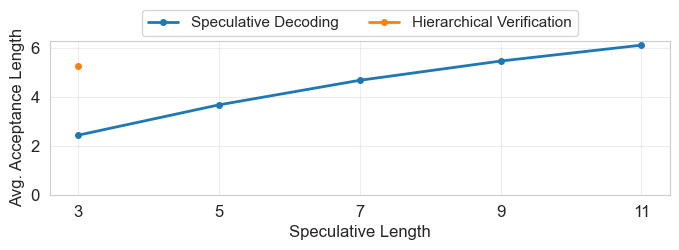

saved: plots_results/Qwen3-32B__PLUS__Qwen3-0.6B/figure_1_average_acceptance_length.pdf
saved: plots_results/Qwen3-32B__PLUS__Qwen3-0.6B/figure_1_average_acceptance_length.png


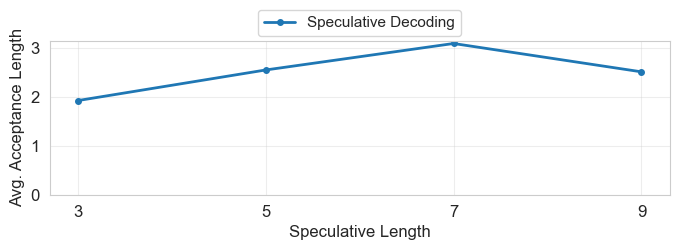

In [5]:
def plot_figure_1_average_acceptance_length():
    fig_name = "figure_1_average_acceptance_length"

    if not nonempty(
        motivation_df,
        ["model_pair", "speculative_length", "method_pretty", "avg_target_accept_len"],
        fig_name,
    ):
        return

    for model_pair in model_pairs:
        df = motivation_df[motivation_df["model_pair"] == model_pair].copy()
        if df.empty:
            continue

        agg = aggregate_mean(
            df,
            ["speculative_length", "method_pretty"],
            "avg_target_accept_len",
        )

        if agg.empty:
            print(f"[skip] {fig_name}: no rows for {model_pair}")
            continue

        methods = sorted_methods(agg["method_pretty"].unique())
        colors = color_map(methods)

        fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)

        for method in methods:
            sub = agg[agg["method_pretty"] == method].sort_values("speculative_length")
            ax.plot(
                sub["speculative_length"],
                sub["avg_target_accept_len"],
                marker="o",
                linewidth=2,
                markersize=4,
                label=method,
                color=colors[method],
            )

        format_line_ax(
            ax,
            xlabel="Speculative Length",
            ylabel="Avg. Acceptance Length",
            title=None,
        )
        ax.set_xticks(sorted(agg["speculative_length"].unique()))
        ax.set_ylim(bottom=0.0)

        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(
            by_label.values(),
            by_label.keys(),
            loc="upper center",
            bbox_to_anchor=(0.5, 1.25),
            ncol=3,
            fancybox=True,
            shadow=False,
            fontsize=11,
        )

        save_fig(fig, get_model_out_dir(model_pair), fig_name)
        plt.show()

plot_figure_1_average_acceptance_length()


saved: plots_results/figure_1b_sync_average_acceptance_length_by_model_family.pdf
saved: plots_results/figure_1b_sync_average_acceptance_length_by_model_family.png


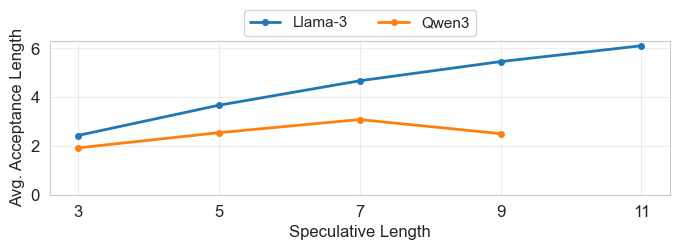

In [9]:
def plot_figure_1b_sync_average_acceptance_length_by_model_family():
    fig_name = "figure_1b_sync_average_acceptance_length_by_model_family"

    if not nonempty(
        motivation_df,
        ["model_pair", "speculative_length", "method", "avg_target_accept_len"],
        fig_name,
    ):
        return

    df = motivation_df[motivation_df["method"] == "sync"].copy()
    if df.empty:
        print(f"[skip] {fig_name}: no sync rows")
        return

    def model_family(model_pair):
        low = str(model_pair).lower()
        if "llama" in low:
            return "Llama-3"
        if "qwen" in low:
            return "Qwen3"
        return None

    df["model_family"] = df["model_pair"].map(model_family)
    df = df[df["model_family"].notna()].copy()

    agg = aggregate_mean(
        df,
        ["speculative_length", "model_family"],
        "avg_target_accept_len",
    )

    if agg.empty:
        print(f"[skip] {fig_name}: no Llama-3/Qwen3 sync rows")
        return

    families = ["Llama-3", "Qwen3"]
    families = [family for family in families if family in set(agg["model_family"])]
    colors = color_map(families)

    fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)

    for family in families:
        sub = agg[agg["model_family"] == family].sort_values("speculative_length")
        ax.plot(
            sub["speculative_length"],
            sub["avg_target_accept_len"],
            marker="o",
            linewidth=2,
            markersize=4,
            label=family,
            color=colors[family],
        )

    format_line_ax(
        ax,
        xlabel="Speculative Length",
        ylabel="Avg. Acceptance Length",
        title=None,
    )
    ax.set_xticks(sorted(agg["speculative_length"].unique()))
    ax.set_ylim(bottom=0.0)

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(
        by_label.values(),
        by_label.keys(),
        loc="upper center",
        bbox_to_anchor=(0.5, 1.25),
        ncol=2,
        fancybox=True,
        shadow=False,
        fontsize=11,
    )

    save_fig(fig, "./plots_results/", fig_name)
    plt.show()

plot_figure_1b_sync_average_acceptance_length_by_model_family()

## Figure 2. Throughput per speculative length

saved: plots_results/Llama-3.3-70B-Instruct__PLUS__Llama-3.2-1B-Instruct/figure_2_throughput.pdf
saved: plots_results/Llama-3.3-70B-Instruct__PLUS__Llama-3.2-1B-Instruct/figure_2_throughput.png


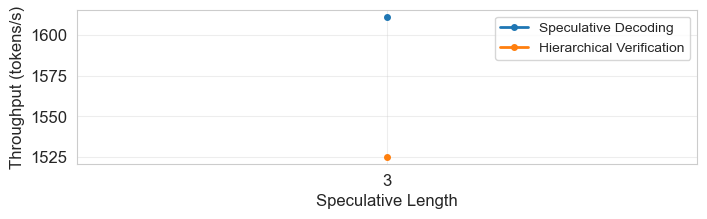

saved: plots_results/Qwen3-32B__PLUS__Qwen3-0.6B/figure_2_throughput.pdf
saved: plots_results/Qwen3-32B__PLUS__Qwen3-0.6B/figure_2_throughput.png


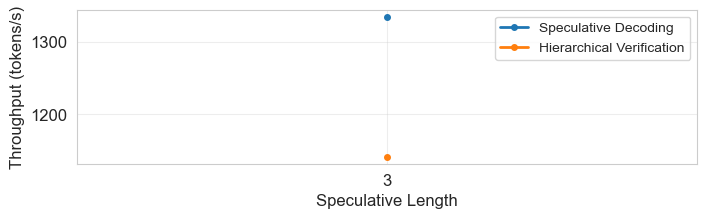

In [6]:
def plot_figure_2_throughput():
    fig_name = "figure_2_throughput"

    if not nonempty(
        results_df,
        ["model_pair", "speculative_length", "method_pretty", "throughput"],
        fig_name,
    ):
        return

    for model_pair in model_pairs:
        df = results_df[results_df["model_pair"] == model_pair].copy()
        if df.empty:
            continue

        agg = aggregate_mean(
            df,
            ["speculative_length", "method_pretty"],
            "throughput",
        )

        if agg.empty:
            print(f"[skip] {fig_name}: no rows for {model_pair}")
            continue

        methods = sorted_methods(agg["method_pretty"].unique())
        colors = color_map(methods)

        fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)

        for method in methods:
            sub = agg[agg["method_pretty"] == method].sort_values("speculative_length")
            ax.plot(
                sub["speculative_length"],
                sub["throughput"],
                marker="o",
                linewidth=2,
                markersize=4,
                label=method,
                color=colors[method],
            )

        format_line_ax(
            ax,
            xlabel="Speculative Length",
            ylabel="Throughput (tokens/s)",
            title=None,
        )
        ax.set_xticks(sorted(agg["speculative_length"].unique()))

        save_fig(fig, get_model_out_dir(model_pair), fig_name)
        plt.show()

plot_figure_2_throughput()


## Figure 3. Acceptance length trace, method = sync

saved: plots_results/Llama-3.3-70B-Instruct__PLUS__Llama-3.2-1B-Instruct/figure_3_acceptance_length_trace_k3.pdf
saved: plots_results/Llama-3.3-70B-Instruct__PLUS__Llama-3.2-1B-Instruct/figure_3_acceptance_length_trace_k3.png


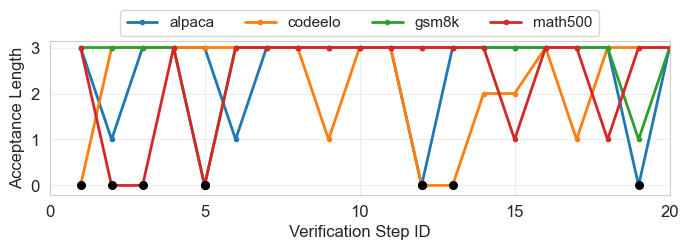

saved: plots_results/Qwen3-32B__PLUS__Qwen3-0.6B/figure_3_acceptance_length_trace_k3.pdf
saved: plots_results/Qwen3-32B__PLUS__Qwen3-0.6B/figure_3_acceptance_length_trace_k3.png


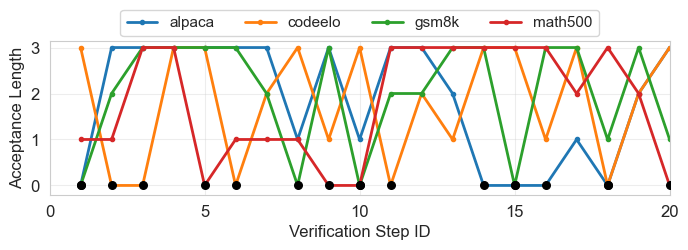

In [16]:
def plot_figure_3_acceptance_length_trace():
    fig_name = "figure_3_acceptance_length_trace"

    if not nonempty(
        trace_df,
        ["model_pair", "method", "dataset", "speculative_length", "target_accept_len_by_request"],
        fig_name,
    ):
        return

    for model_pair in model_pairs:
        df = trace_df[
            (trace_df["model_pair"] == model_pair)
            & (trace_df["method"] == "sync")
            & (trace_df["speculative_length"] == TRACE_SPECULATIVE_LENGTH)
        ].copy()

        if df.empty:
            print(f"[skip] {fig_name}: no sync k={TRACE_SPECULATIVE_LENGTH} rows for {model_pair}")
            continue

        long_rows = []
        for _, row in df.iterrows():
            series_df = trace_row_to_series(row)
            if series_df.empty:
                continue
            series_df["dataset"] = row["dataset"]
            long_rows.append(series_df)

        if not long_rows:
            print(f"[skip] {fig_name}: no trace series for {model_pair}")
            continue

        long_df = pd.concat(long_rows, ignore_index=True)
        long_df = long_df.dropna(subset=["target_accept_len"])

        datasets = sorted_datasets(long_df["dataset"].unique())
        colors = color_map(datasets)

        fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)

        for dataset in datasets:
            sub_all = long_df[long_df["dataset"] == dataset].copy()
            if sub_all.empty:
                continue

            request = sorted(sub_all["request"].unique())[0]
            sub = (
                sub_all[sub_all["request"] == request]
                .sort_values("step_id")
                .copy()
            )

            ax.plot(
                sub["step_id"],
                sub["target_accept_len"],
                marker="o",
                linewidth=2,
                markersize=3,
                label=dataset,
                color=colors[dataset],
            )

            miss = sub[sub["target_accept_len"] == 0]
            if not miss.empty:
                ax.scatter(
                    miss["step_id"],
                    miss["target_accept_len"],
                    s=30,
                    color="black",
                    zorder=5,
                )

        format_line_ax(
            ax,
            xlabel="Verification Step ID",
            ylabel="Acceptance Length",
            title=None,
        )
        ax.set_xticks([0, 5, 10, 15, 20])
        ax.set_xlim(left=0, right=20)
        ax.set_ylim(bottom=0.0 - 0.2)

        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(
            by_label.values(),
            by_label.keys(),
            loc="upper center",
            bbox_to_anchor=(0.5, 1.25),
            ncol=4,
            fancybox=True,
            shadow=False,
            fontsize=11,
        )

        save_fig(fig, get_model_out_dir(model_pair), f"{fig_name}_k{TRACE_SPECULATIVE_LENGTH}")
        plt.show()

plot_figure_3_acceptance_length_trace()

## Figure 4. Misspeculation probability per speculative length, method = sync

saved: plots_results/Llama-3.3-70B-Instruct__PLUS__Llama-3.2-1B-Instruct/figure_4_misspeculation_probability.pdf
saved: plots_results/Llama-3.3-70B-Instruct__PLUS__Llama-3.2-1B-Instruct/figure_4_misspeculation_probability.png


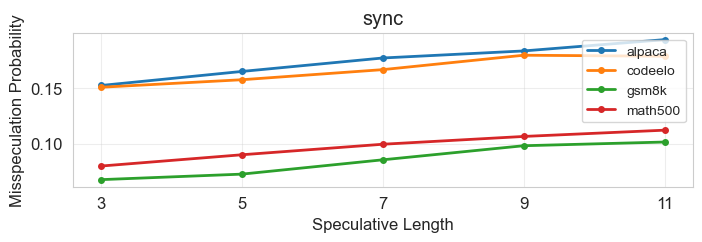

saved: plots_results/Qwen3-32B__PLUS__Qwen3-0.6B/figure_4_misspeculation_probability.pdf
saved: plots_results/Qwen3-32B__PLUS__Qwen3-0.6B/figure_4_misspeculation_probability.png


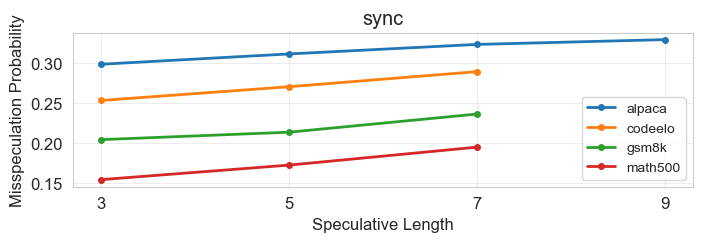

In [17]:
def plot_figure_4_misspeculation_probability():
    fig_name = "figure_4_misspeculation_probability"

    if not nonempty(
        motivation_df,
        ["model_pair", "method", "dataset", "speculative_length", "misspeculation_probability"],
        fig_name,
    ):
        return

    for model_pair in model_pairs:
        df = motivation_df[
            (motivation_df["model_pair"] == model_pair)
            & (motivation_df["method"] == "sync")
        ].copy()

        if df.empty:
            print(f"[skip] {fig_name}: no sync rows for {model_pair}")
            continue

        agg = aggregate_mean(
            df,
            ["dataset", "speculative_length"],
            "misspeculation_probability",
        )

        if agg.empty:
            print(f"[skip] {fig_name}: no rows for {model_pair}")
            continue

        datasets = sorted_datasets(agg["dataset"].unique())
        colors = color_map(datasets)

        fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)

        for dataset in datasets:
            sub = agg[agg["dataset"] == dataset].sort_values("speculative_length")
            ax.plot(
                sub["speculative_length"],
                sub["misspeculation_probability"],
                marker="o",
                linewidth=2,
                markersize=4,
                label=dataset,
                color=colors[dataset],
            )

        format_line_ax(
            ax,
            xlabel="Speculative Length",
            ylabel="Misspeculation Probability",
            title="sync",
        )
        ax.set_xticks(sorted(agg["speculative_length"].unique()))

        save_fig(fig, get_model_out_dir(model_pair), fig_name)
        plt.show()

plot_figure_4_misspeculation_probability()


## Figure 5. Intra-batch distribution, method = sync, k = 3 and k = 7

saved: plots_results/Llama-3.3-70B-Instruct__PLUS__Llama-3.2-1B-Instruct/figure_4_misspeculation_probability.pdf
saved: plots_results/Llama-3.3-70B-Instruct__PLUS__Llama-3.2-1B-Instruct/figure_4_misspeculation_probability.png


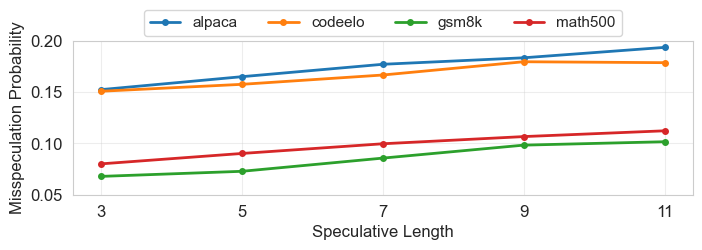

saved: plots_results/Qwen3-32B__PLUS__Qwen3-0.6B/figure_4_misspeculation_probability.pdf
saved: plots_results/Qwen3-32B__PLUS__Qwen3-0.6B/figure_4_misspeculation_probability.png


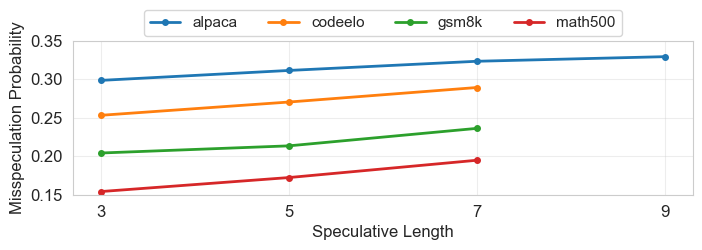

In [18]:
def plot_figure_4_misspeculation_probability():
    fig_name = "figure_4_misspeculation_probability"

    if not nonempty(
        motivation_df,
        ["model_pair", "method", "dataset", "speculative_length", "misspeculation_probability"],
        fig_name,
    ):
        return

    for model_pair in model_pairs:
        df = motivation_df[
            (motivation_df["model_pair"] == model_pair)
            & (motivation_df["method"] == "sync")
        ].copy()

        if df.empty:
            print(f"[skip] {fig_name}: no sync rows for {model_pair}")
            continue

        agg = aggregate_mean(
            df,
            ["dataset", "speculative_length"],
            "misspeculation_probability",
        )

        if agg.empty:
            print(f"[skip] {fig_name}: no rows for {model_pair}")
            continue

        datasets = sorted_datasets(agg["dataset"].unique())
        colors = color_map(datasets)

        fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)

        for dataset in datasets:
            sub = agg[agg["dataset"] == dataset].sort_values("speculative_length")
            ax.plot(
                sub["speculative_length"],
                sub["misspeculation_probability"],
                marker="o",
                linewidth=2,
                markersize=4,
                label=dataset,
                color=colors[dataset],
            )

        format_line_ax(
            ax,
            xlabel="Speculative Length",
            ylabel="Misspeculation Probability",
            title=None,
        )
        ax.set_xticks(sorted(agg["speculative_length"].unique()))

        ymin = float(agg["misspeculation_probability"].min())
        ymax = float(agg["misspeculation_probability"].max())
        tick_min = np.floor(ymin / 0.05) * 0.05
        tick_max = np.ceil(ymax / 0.05) * 0.05
        if tick_min == tick_max:
            tick_max = tick_min + 0.05

        yticks = np.arange(tick_min, tick_max + 1e-9, 0.05)
        ax.set_ylim(tick_min, tick_max)
        ax.set_yticks(yticks)

        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(
            by_label.values(),
            by_label.keys(),
            loc="upper center",
            bbox_to_anchor=(0.5, 1.25),
            ncol=4,
            fancybox=True,
            shadow=False,
            fontsize=11,
        )

        save_fig(fig, get_model_out_dir(model_pair), fig_name)
        plt.show()

plot_figure_4_misspeculation_probability()

## Figure 6. Target match probability, method = sync

saved: plots_results/Llama-3.3-70B-Instruct__PLUS__Llama-3.2-1B-Instruct/figure_6_target_match_probability_k3.pdf
saved: plots_results/Llama-3.3-70B-Instruct__PLUS__Llama-3.2-1B-Instruct/figure_6_target_match_probability_k3.png


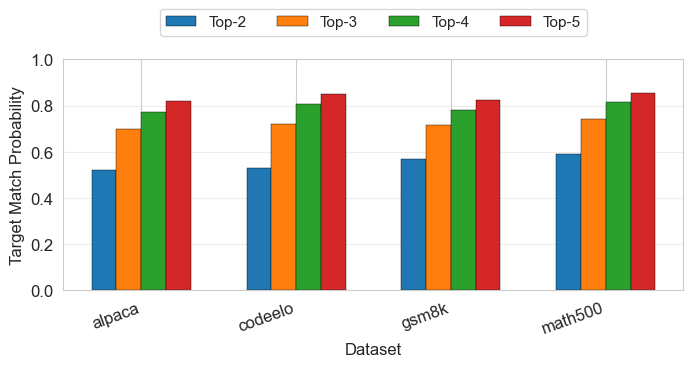

saved: plots_results/Qwen3-32B__PLUS__Qwen3-0.6B/figure_6_target_match_probability_k3.pdf
saved: plots_results/Qwen3-32B__PLUS__Qwen3-0.6B/figure_6_target_match_probability_k3.png


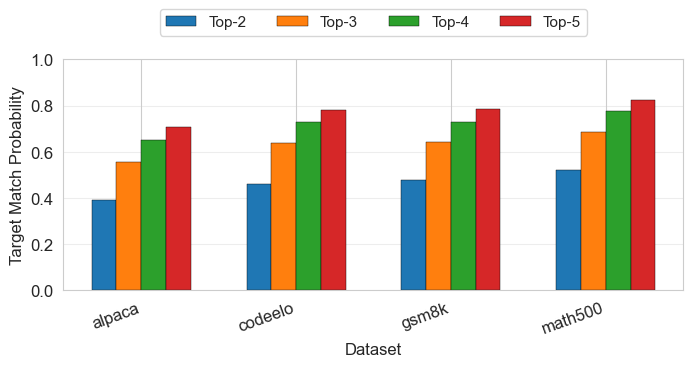

In [20]:
def plot_figure_6_target_match_probability():
    fig_name = "figure_6_target_match_probability"

    if not nonempty(
        insight_df,
        ["model_pair", "method", "dataset", "speculative_length", "misspeculation_topk_inclusiveness"],
        fig_name,
    ):
        return

    for model_pair in model_pairs:
        df = insight_df[
            (insight_df["model_pair"] == model_pair)
            & (insight_df["method"] == "sync")
            & (insight_df["speculative_length"] == TOPK_SPECULATIVE_LENGTH)
        ].copy()

        if df.empty:
            print(f"[skip] {fig_name}: no sync k={TOPK_SPECULATIVE_LENGTH} rows for {model_pair}")
            continue

        rows = []
        for _, row in df.iterrows():
            base = {
                "dataset": row["dataset"],
                "speculative_length": row["speculative_length"],
            }
            base.update(topk_dict_to_row(row["misspeculation_topk_inclusiveness"]))
            rows.append(base)

        prob_df = pd.DataFrame(rows)
        datasets = sorted_datasets(prob_df["dataset"].unique())

        topks = [f"top{k}_prob" for k in range(2, 6)]
        topk_labels = [f"Top-{k}" for k in range(2, 6)]

        x = np.arange(len(datasets))
        bar_width = 0.16
        colors = color_map(topk_labels)

        fig, ax = plt.subplots(figsize=FIGSIZE_TALL)

        for i, (col, label) in enumerate(zip(topks, topk_labels)):
            values = [
                prob_df.loc[prob_df["dataset"] == dataset, col].mean()
                for dataset in datasets
            ]
            positions = x - (bar_width * len(topks)) / 2 + i * bar_width + bar_width / 2
            ax.bar(
                positions,
                values,
                width=bar_width,
                label=label,
                color=colors[label],
                edgecolor="black",
                linewidth=0.3,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(datasets, rotation=20, ha="right")
        ax.set_xlabel("Dataset")
        ax.set_ylabel("Target Match Probability")
        ax.set_title(None)
        ax.set_ylim(0.0, 1.0)
        ax.set_yticks(np.arange(0.0, 1.01, 0.2))
        ax.grid(True, axis="y", alpha=0.35)

        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(
            by_label.values(),
            by_label.keys(),
            loc="upper center",
            bbox_to_anchor=(0.5, 1.25),
            ncol=4,
            fancybox=True,
            shadow=False,
            fontsize=11,
        )

        save_fig(fig, get_model_out_dir(model_pair), f"{fig_name}_k{TOPK_SPECULATIVE_LENGTH}")
        plt.show()

plot_figure_6_target_match_probability()

## Figure 7. Misspeculation confidence correlation, top-1 confidence

saved: plots_results/Llama-3.3-70B-Instruct__PLUS__Llama-3.2-1B-Instruct/figure_7_misspeculation_top1_confidence_k3.pdf
saved: plots_results/Llama-3.3-70B-Instruct__PLUS__Llama-3.2-1B-Instruct/figure_7_misspeculation_top1_confidence_k3.png


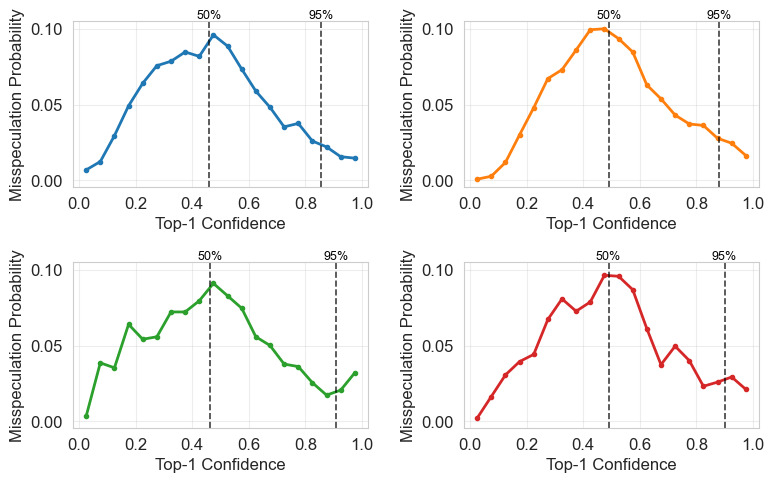

saved: plots_results/Qwen3-32B__PLUS__Qwen3-0.6B/figure_7_misspeculation_top1_confidence_k3.pdf
saved: plots_results/Qwen3-32B__PLUS__Qwen3-0.6B/figure_7_misspeculation_top1_confidence_k3.png


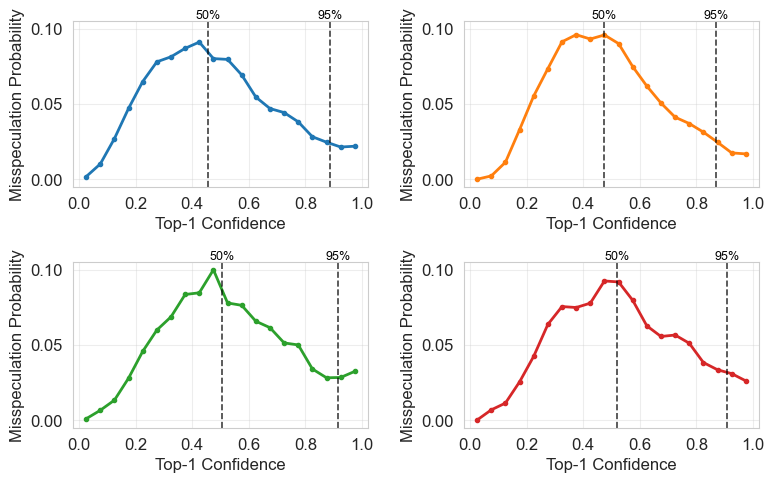

In [42]:
def expand_confidence_rows(df, value_col):
    rows = []

    for _, row in df.iterrows():
        corr_rows = row.get("misspeculation_confidence_correlation")
        if not isinstance(corr_rows, list):
            continue

        for corr in corr_rows:
            if not isinstance(corr, dict):
                continue

            value = corr.get(value_col)
            if value is None:
                continue

            rows.append(
                {
                    "dataset": row["dataset"],
                    "method": row["method"],
                    "speculative_length": row["speculative_length"],
                    "value": value,
                }
            )

    return pd.DataFrame(rows)

def probability_hist_line(values, bins):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        centers = (bins[:-1] + bins[1:]) / 2.0
        return centers, np.zeros_like(centers)

    counts, edges = np.histogram(values, bins=bins)
    probs = counts / counts.sum() if counts.sum() > 0 else np.zeros_like(counts, dtype=float)
    centers = (edges[:-1] + edges[1:]) / 2.0

    return centers, probs

def plot_confidence_correlation_grid(value_col, xlabel, fig_name):
    if not nonempty(
        insight_df,
        ["model_pair", "method", "dataset", "speculative_length", "misspeculation_confidence_correlation"],
        fig_name,
    ):
        return

    for model_pair in model_pairs:
        df = insight_df[
            (insight_df["model_pair"] == model_pair)
            & (insight_df["method"] == "sync")
            & (insight_df["speculative_length"] == CONF_SPECULATIVE_LENGTH)
        ].copy()

        if df.empty:
            print(f"[skip] {fig_name}: no sync k={CONF_SPECULATIVE_LENGTH} rows for {model_pair}")
            continue

        long_df = expand_confidence_rows(df, value_col=value_col)
        if long_df.empty:
            print(f"[skip] {fig_name}: no confidence rows for {model_pair}")
            continue

        datasets = sorted_datasets(long_df["dataset"].unique())
        n = len(datasets)
        ncols = 2
        nrows = int(np.ceil(n / ncols))

        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=ncols,
            figsize=FIGSIZE_GRID,
            sharex=True,
            sharey=True,
        )

        if not isinstance(axes, np.ndarray):
            axes = np.array([axes])

        axes = axes.flatten()
        colors = color_map(datasets)

        if value_col == "residual_confidence":
            lo = min(0.0, float(long_df["value"].min()))
            hi = max(1.0, float(long_df["value"].max()))
            bins = np.linspace(lo, hi, 21)
        else:
            lo = 0.0
            hi = 1.0
            bins = np.linspace(lo, hi, 21)

        for i, dataset in enumerate(datasets):
            ax = axes[i]
            values = long_df.loc[long_df["dataset"] == dataset, "value"].dropna().values
            centers, probs = probability_hist_line(values, bins=bins)

            ax.plot(
                centers,
                probs,
                marker="o",
                linewidth=2,
                markersize=3,
                color=colors[dataset],
            )

            quantiles = {
                "50%": 0.50,
                "95%": 0.95,
            #    "99%": 0.99,
            }

            if len(values) > 0:
                for q_label, q in quantiles.items():
                    q_value = np.quantile(values, q)
                    ax.axvline(
                        q_value,
                        color="black",
                        linestyle="--",
                        linewidth=1.2,
                        alpha=0.75,
                    )
                    ax.text(
                        q_value,
                        1.07,
                        q_label,
                        transform=ax.get_xaxis_transform(),
                        va="top",
                        ha="center",
                        fontsize=9,
                        color="black",
                    )
            ax.set_title(None)
            ax.set_xlabel(xlabel)
            ax.set_ylabel("Misspeculation Probability")
            ax.grid(True, alpha=0.35)

            ax.tick_params(
                axis="both",
                which="both",
                labelbottom=True,
                labelleft=True,
            )

            ax.set_xticks(np.linspace(lo, hi, 6))

        for j in range(len(datasets), len(axes)):
            axes[j].axis("off")

        fig.tight_layout()

        save_fig(fig, get_model_out_dir(model_pair), f"{fig_name}_k{CONF_SPECULATIVE_LENGTH}")
        plt.show()

plot_confidence_correlation_grid(
    value_col="top1_confidence",
    xlabel="Top-1 Confidence",
    fig_name="figure_7_misspeculation_top1_confidence",
)


## Figure 8. Misspeculation confidence correlation, residual confidence

saved: plots_results/Llama-3.3-70B-Instruct__PLUS__Llama-3.2-1B-Instruct/figure_8_misspeculation_residual_confidence_k3.pdf
saved: plots_results/Llama-3.3-70B-Instruct__PLUS__Llama-3.2-1B-Instruct/figure_8_misspeculation_residual_confidence_k3.png


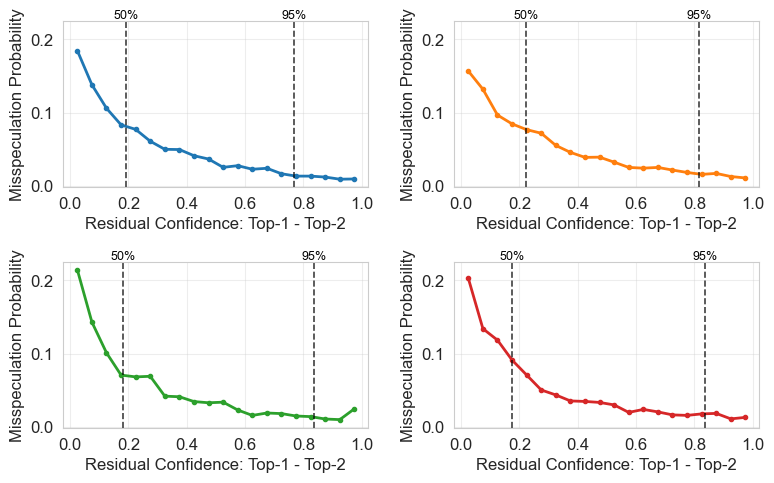

saved: plots_results/Qwen3-32B__PLUS__Qwen3-0.6B/figure_8_misspeculation_residual_confidence_k3.pdf
saved: plots_results/Qwen3-32B__PLUS__Qwen3-0.6B/figure_8_misspeculation_residual_confidence_k3.png


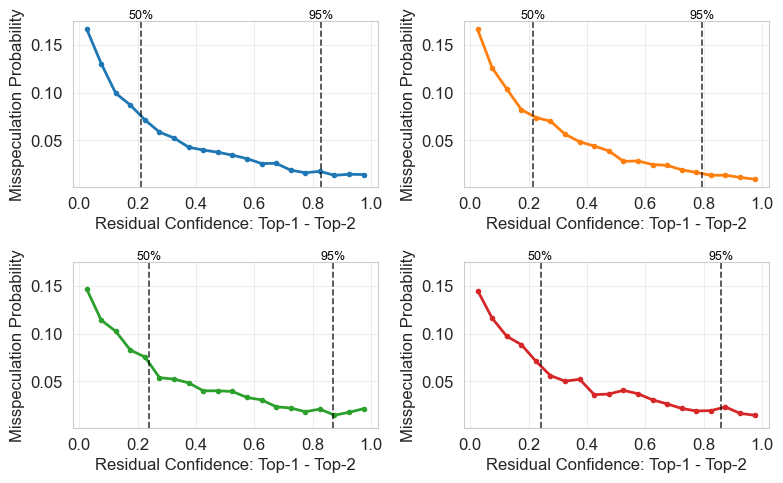

In [43]:
plot_confidence_correlation_grid(
    value_col="residual_confidence",
    xlabel="Residual Confidence: Top-1 - Top-2",
    fig_name="figure_8_misspeculation_residual_confidence",
)


## Raw dataframe previews

In [ ]:
display(motivation_df.head())
display(results_df.head())
display(insight_df.head())
display(trace_df.head())
